# Supervised Learning

This notebook uses simple supervised learning to classify images into classes, without data augmentation

In [1]:

cd ..

/home/lowen/Documents/github/galaxy_class


In [2]:
# install requirements

# if connected to colab


if 'google.colab' in str(get_ipython()):
  print('running on colab')
  %pip install git+https://github.com/henrysky/astroNN.git
else:
  %pip install --upgrade pip
  %pip install -r user-requirements.txt

Note: you may need to restart the kernel to use updated packages.
Ignoring tensorflow: markers 'sys_platform != "linux"' don't match your environment
  Using cached numpy-2.0.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.9.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached tensorflow-2.15.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached h5py-3.16.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (3.0

In [7]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import h5py
import numpy as np
from tensorflow.keras import utils
import os

filepath = 'src/Galaxy10.h5'

if not os.path.exists(filepath):
    print(f"file {filepath} not found")
    print("fetching from http://astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5...")
    os.makedirs('src', exist_ok=True)
    !wget -P src http://astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5

with h5py.File(filepath, 'r') as F:
    images = np.array(F['images'])
    labels = np.array(F['ans'])

# To convert the labels to categorical 10 classes
labels = utils.to_categorical(labels, 10)

# To convert to desirable type
labels = labels.astype(np.float32)
images = images.astype(np.float32)

In [8]:
images.shape

(21785, 69, 69, 3)

In [9]:
# divide images and labels into training and test sets

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.4, random_state=42)

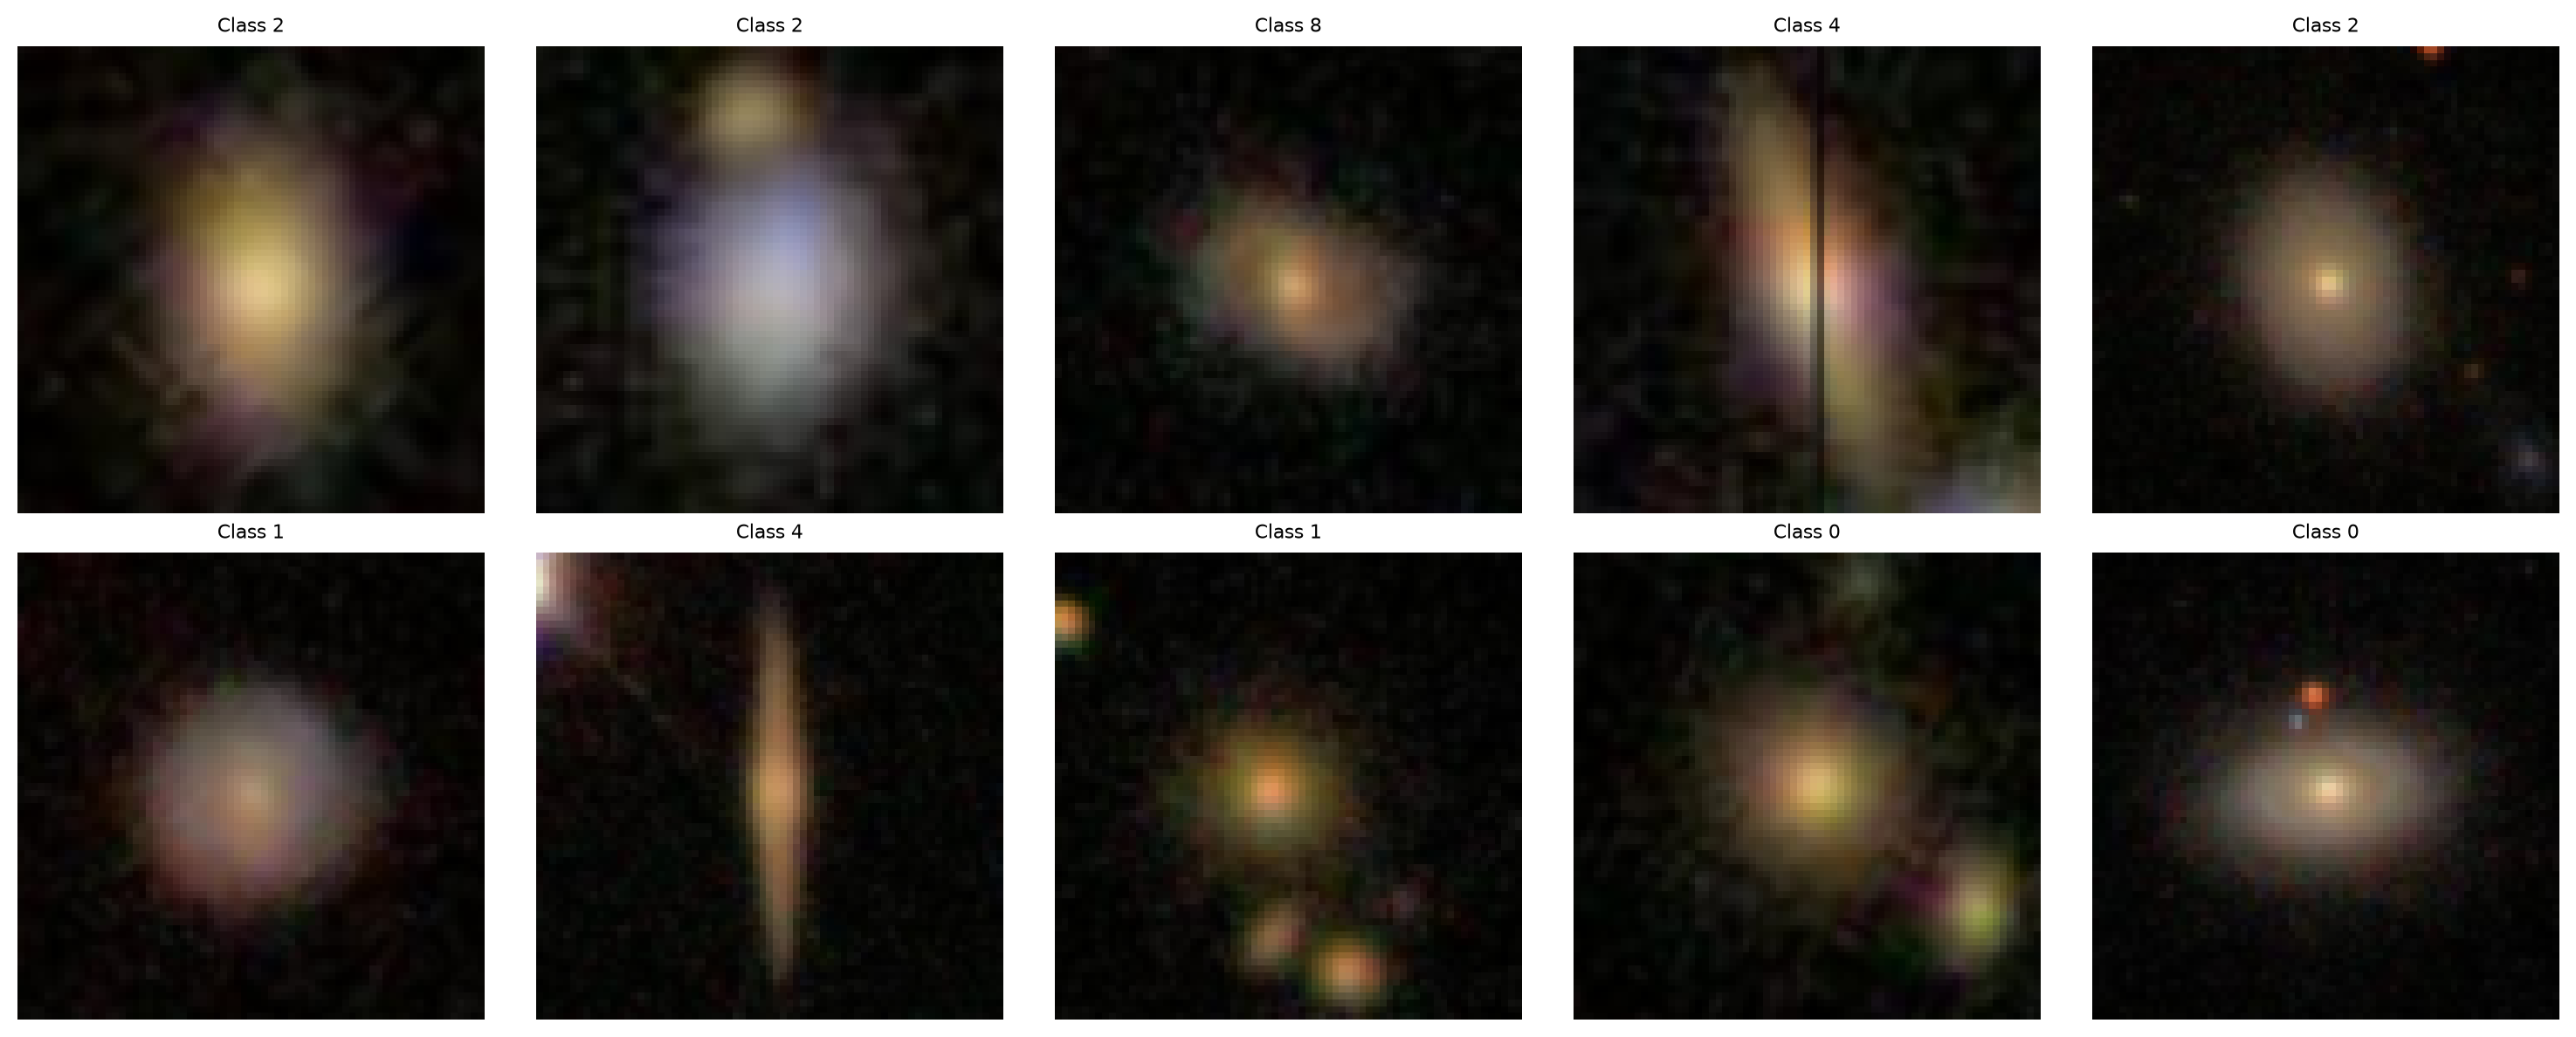

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

idx = np.random.randint(0, y_train.shape[0], size=10)

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train[i].astype(np.uint8))
    ax.set_title(f"Class {np.argmax(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("plots/original.png")
plt.show()

In [11]:
# def center_crop(img, crop_size):
#     h, w = img.shape[:2]
#     start_h = (h - crop_size) // 2
#     start_w = (w - crop_size) // 2
#     return img[start_h:start_h + crop_size, start_w:start_w + crop_size]

# crop_size = 128
# X_train_cropped = np.array([center_crop(img, crop_size) for img in X_train])
# X_test_cropped = np.array([center_crop(img, crop_size) for img in X_test])

# print(X_train_cropped.shape)

In [12]:
from PIL import Image
import numpy as np

X_train_gray = np.array([
    np.array(Image.fromarray(img.astype(np.uint8)).convert('L'))
    for img in X_train
])

X_test_gray = np.array([
    np.array(Image.fromarray(img.astype(np.uint8)).convert('L'))
    for img in X_test
])

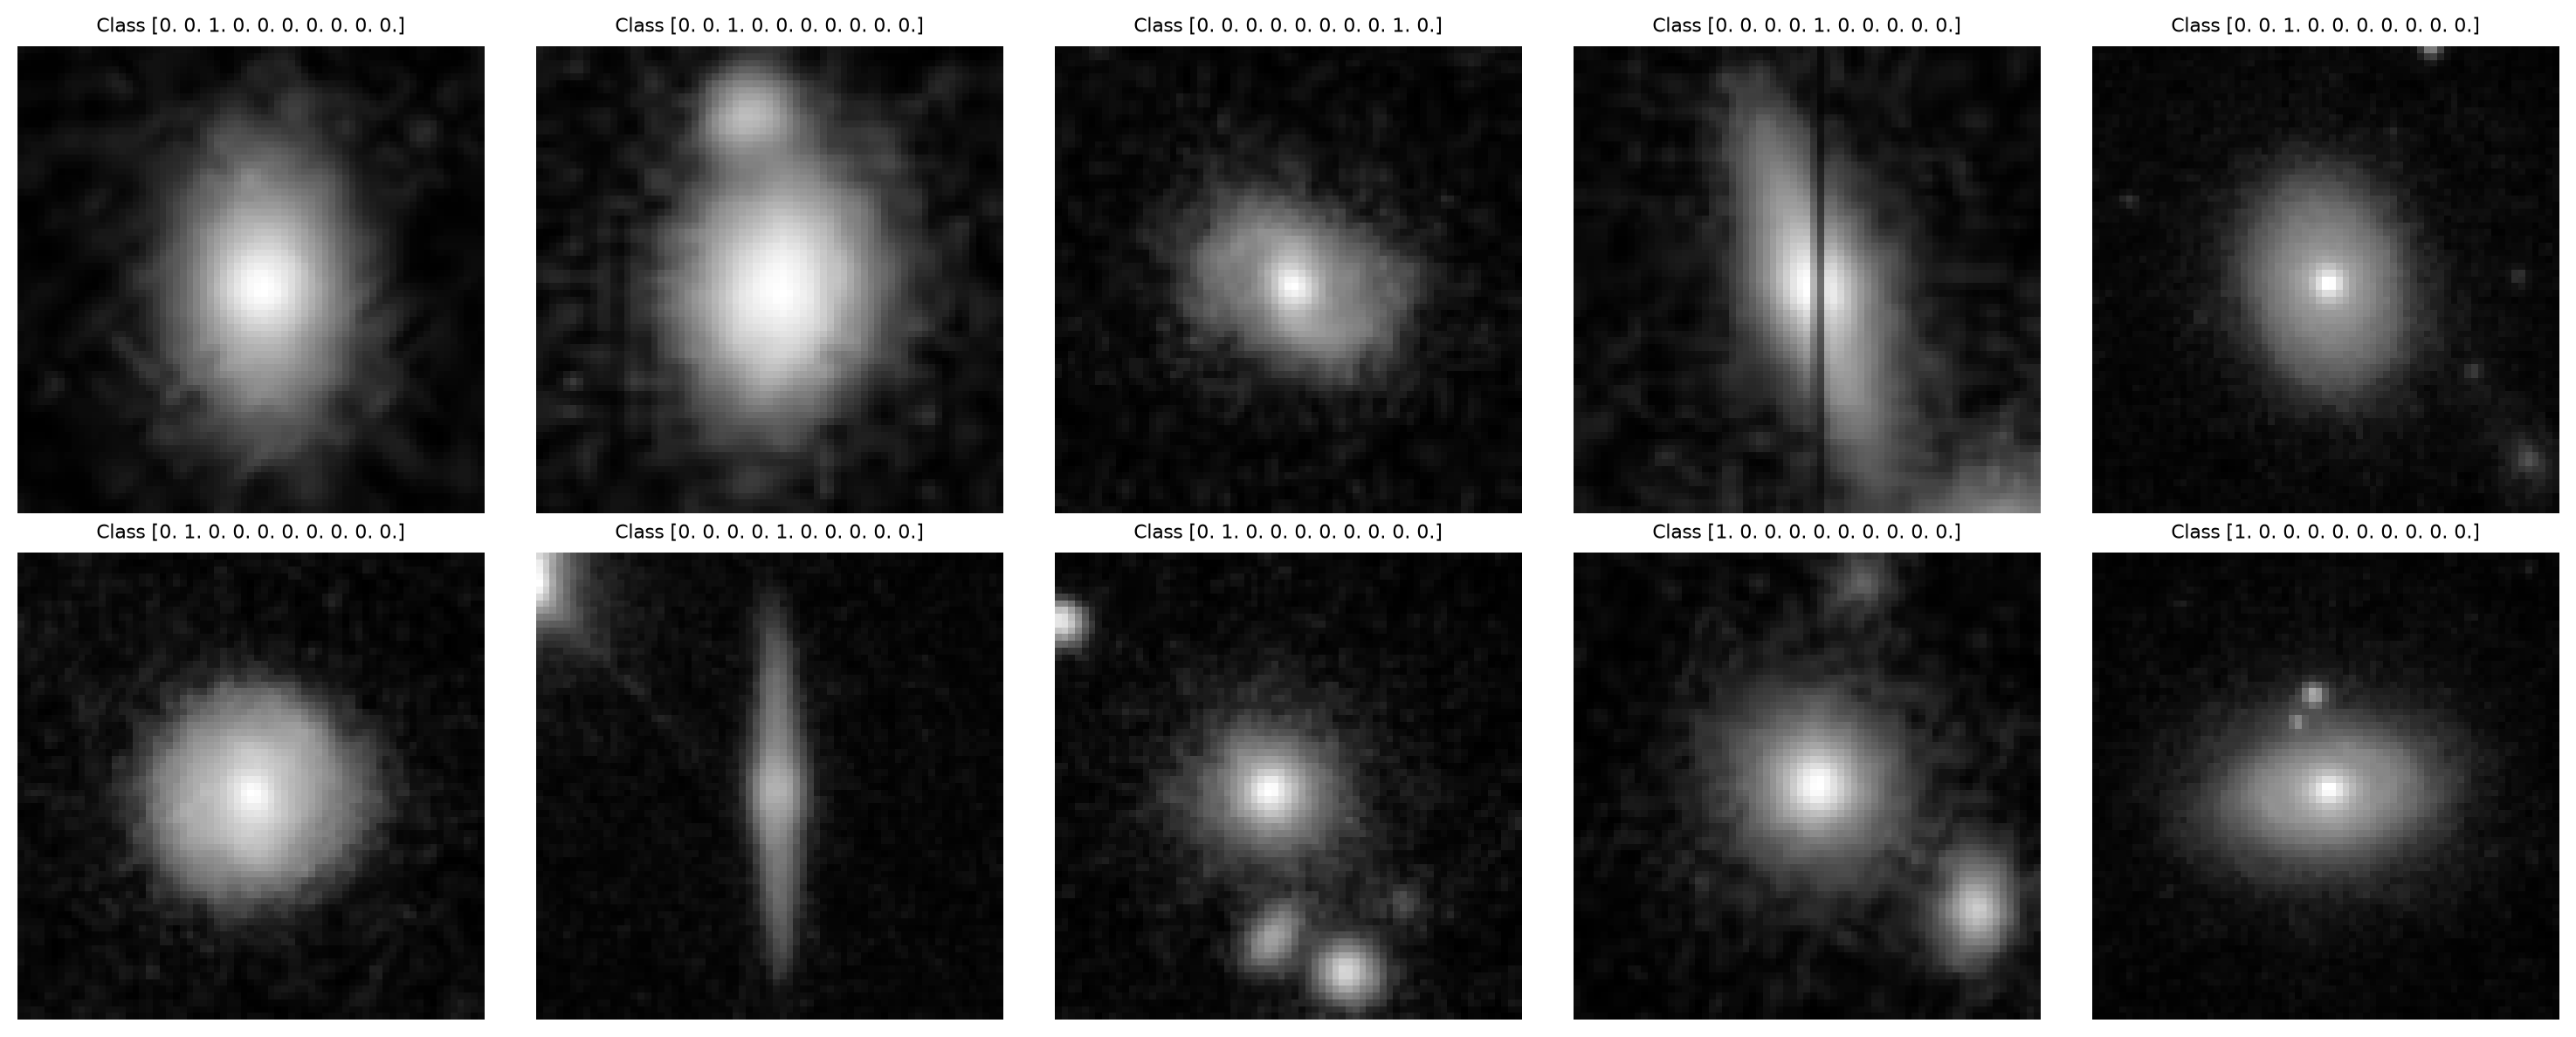

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train_gray[i], cmap="gray")
    ax.set_title(f"Class {y_train[i]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Data Cleaning

1. normalization (min-max)
2. normalization using percentiles
3. gaussian / bilateral filter
4. histogram equalization

In [14]:
# Min-max normalization (per-image)

X_min = X_train_gray.min(axis=(1,2), keepdims=True)  
X_max = X_train_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_train_gray - X_min) / (X_max - X_min + 1e-8)  

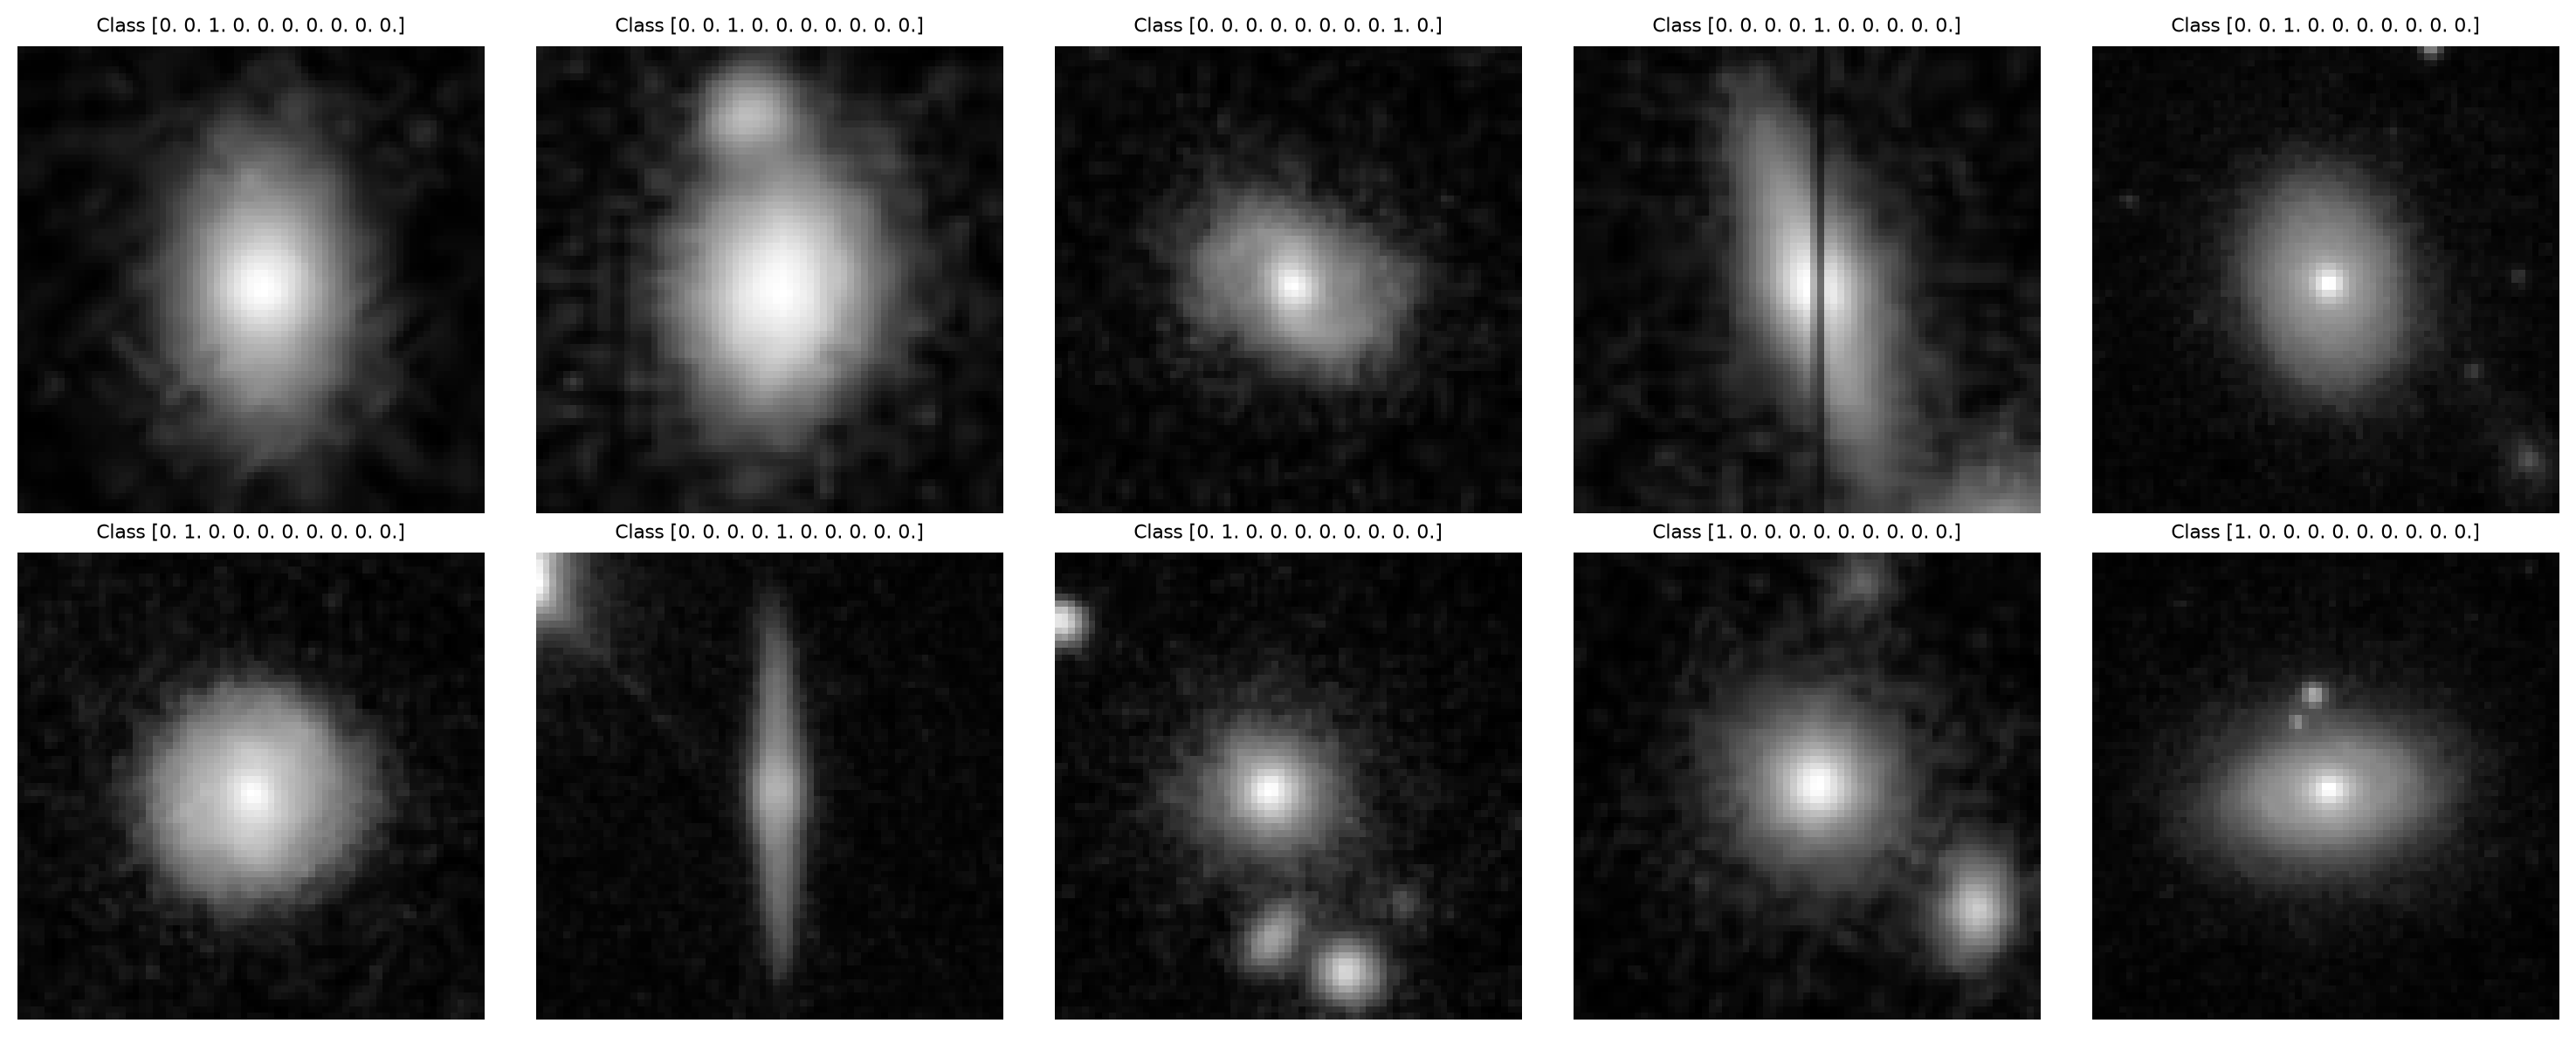

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_norm[i], cmap="gray")
    ax.set_title(f"Class {y_train[i]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("plots/gray.png")
plt.show()

In [16]:
X_norm.shape

(13071, 69, 69)

In [17]:
# gaussian filter on images

from scipy.ndimage import gaussian_filter

X_gauss = gaussian_filter(X_norm, sigma=1, axes=[1,2])

In [18]:
X_gauss.min(), X_gauss.max()

(0.0, 0.9974658839905133)

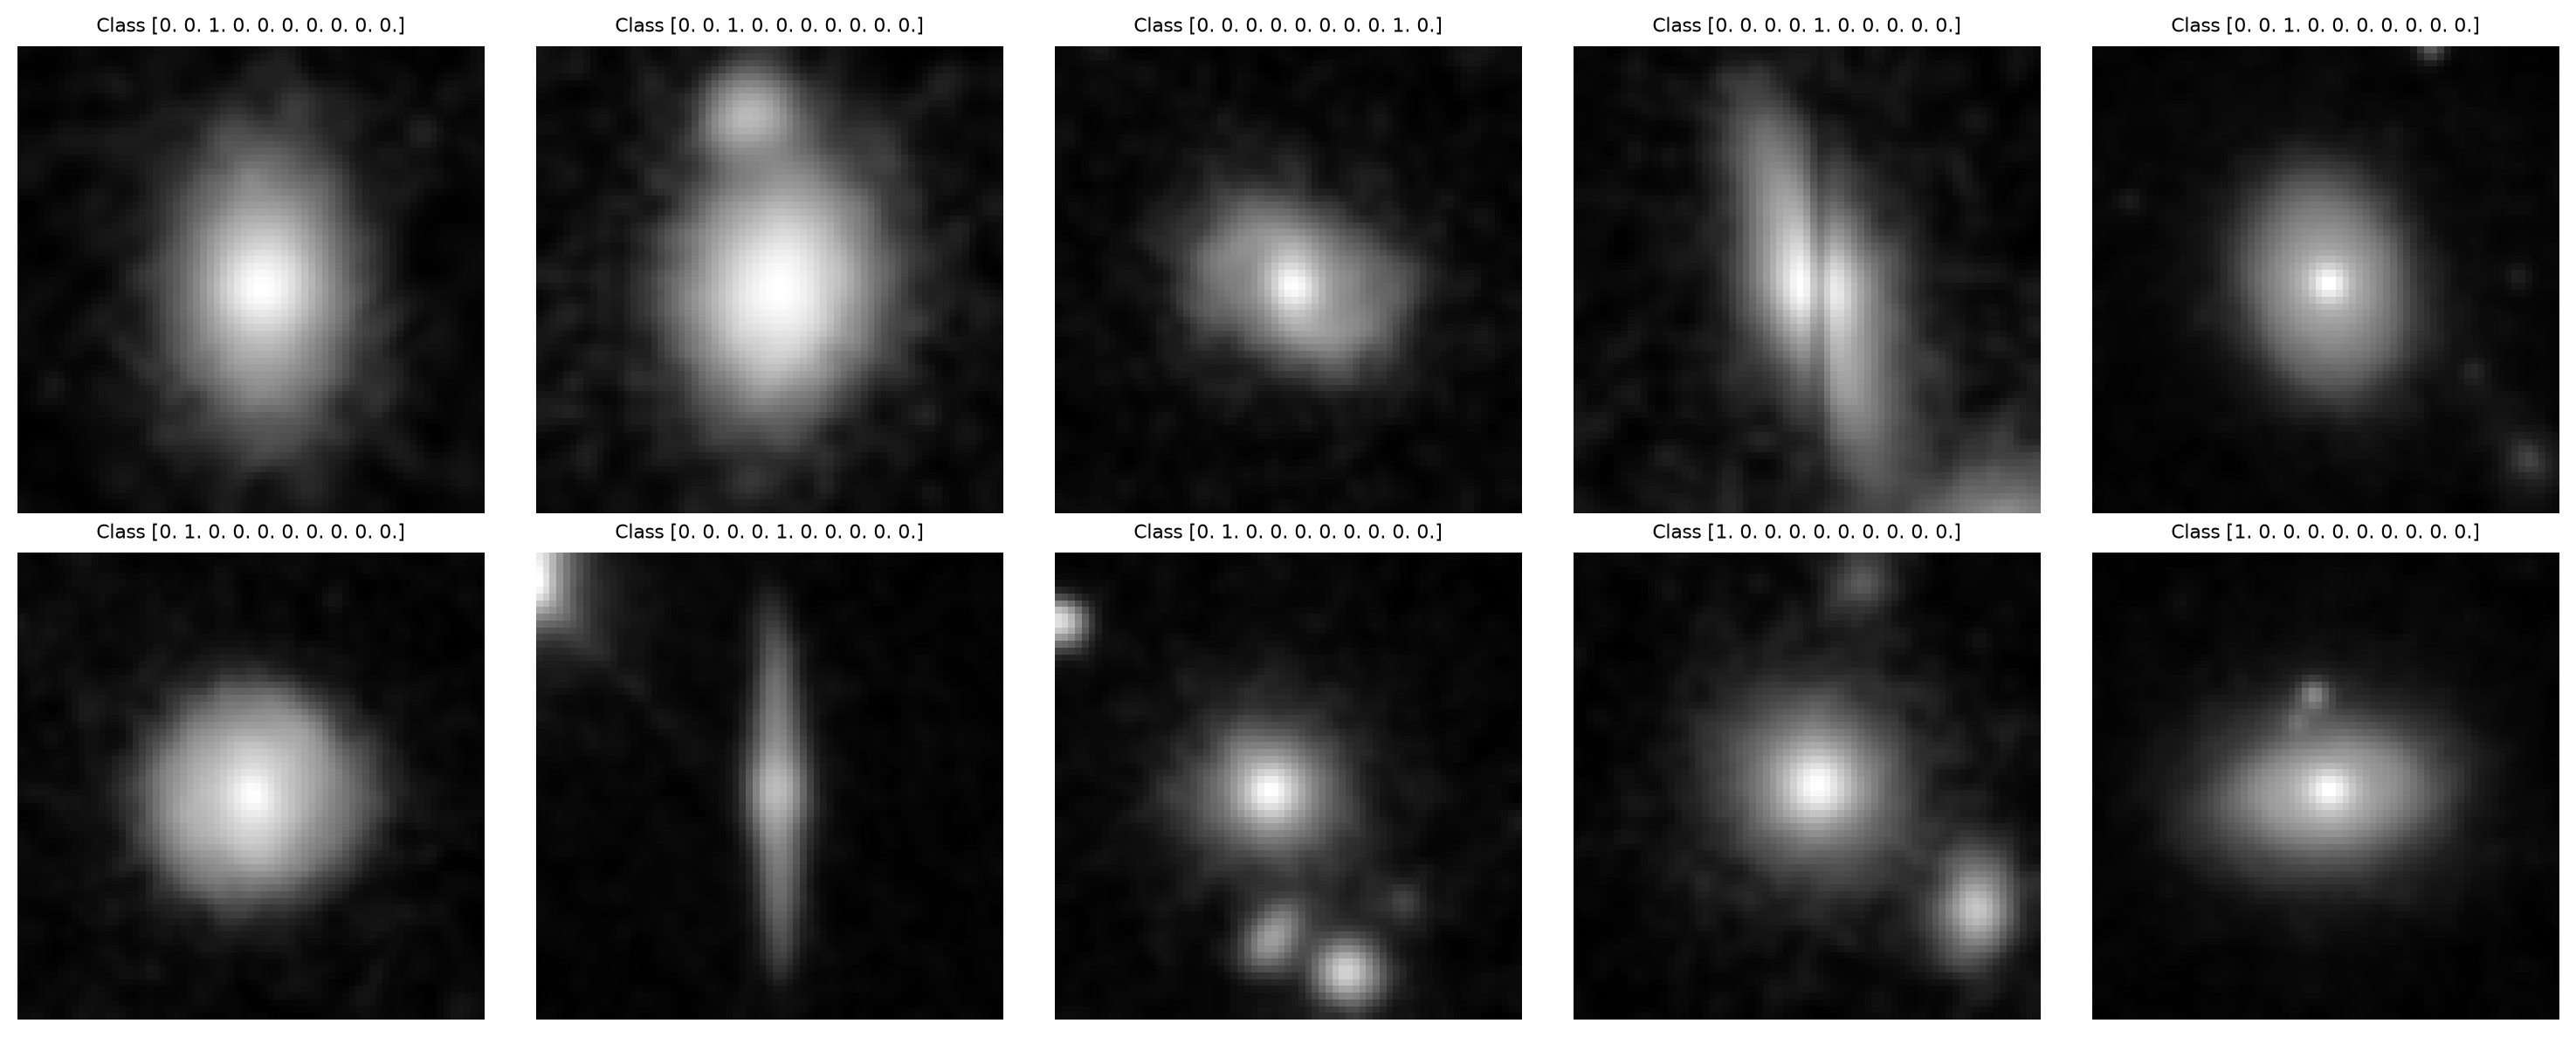

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_gauss[i], cmap="gray")
    ax.set_title(f"Class {y_train[i]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("plots/gaussian_smooth.png")
plt.show()

In [20]:
# train a model on X_norm (without filters) and X_gauss

X_norm.shape, y_train.shape

((13071, 69, 69), (13071, 10))

### Training

#### without filter

In [21]:
# train a CNN model

import tensorflow as tf
from keras import layers, models

In [22]:

input_shape = (X_norm.shape[1], X_norm.shape[1], 1)
model = models.Sequential()

model.add(layers.Input(shape=(69, 69, 1)))

# block 1
model.add(layers.Conv2D(8, (3, 3), activation="relu", padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# block 2
model.add(layers.Conv2D(32, (5, 5), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# block 3
model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# converts feature maps → single vector per feature map
model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(32, activation='relu'))

# model.add(layers.Dropout(0.4))

model.add(layers.Dense(10, activation='softmax'))

2026-07-23 19:16:36.048401: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-23 19:16:39.896162: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-23 19:16:39.897013: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [23]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [24]:
X_norm.shape

(13071, 69, 69)

In [25]:
X_flat = X_norm[..., np.newaxis]
y_labels = np.argmax(y_train, axis=1)


In [26]:
X_flat.shape

(13071, 69, 69, 1)

In [27]:
y_train.shape

(13071, 10)

In [28]:
history = model.fit(
    X_flat, y_train,
    epochs=50,
    batch_size=32,
    shuffle=True
)

2026-07-23 19:16:43.803730: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248924124 exceeds 10% of free system memory.
2026-07-23 19:16:44.335993: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248924124 exceeds 10% of free system memory.


Epoch 1/50


2026-07-23 19:16:47.173707: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-07-23 19:16:49.616242: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-07-23 19:16:54.740953: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-07-23 19:16:55.922305: I external/local_xla/xla/service/service.cc:168] XLA service 0x76b668532640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-23 19:16:55.922327: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2026-07-23 19:16:56.010785: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784827016.157339   36979 device_compiler.

409/409 [==============================] - 19s 11ms/step - loss: 0.2322 - accuracy: 0.4492
Epoch 2/50
409/409 [==============================] - 4s 9ms/step - loss: 0.1684 - accuracy: 0.6289
Epoch 3/50
409/409 [==============================] - 4s 9ms/step - loss: 0.1344 - accuracy: 0.7217
Epoch 4/50
409/409 [==============================] - 4s 10ms/step - loss: 0.1207 - accuracy: 0.7474
Epoch 5/50
409/409 [==============================] - 4s 9ms/step - loss: 0.1130 - accuracy: 0.7644
Epoch 6/50
409/409 [==============================] - 4s 9ms/step - loss: 0.1102 - accuracy: 0.7718
Epoch 7/50
409/409 [==============================] - 3s 9ms/step - loss: 0.1061 - accuracy: 0.7779
Epoch 8/50
409/409 [==============================] - 3s 8ms/step - loss: 0.1025 - accuracy: 0.7899
Epoch 9/50
409/409 [==============================] - 3s 8ms/step - loss: 0.1000 - accuracy: 0.7929
Epoch 10/50
409/409 [==============================] - 3s 8ms/step - loss: 0.0973 - accuracy: 0.8024
Epoch 1

In [29]:
y = model.predict(X_flat)

2026-07-23 19:19:56.986294: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248924124 exceeds 10% of free system memory.
2026-07-23 19:19:57.898263: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248924124 exceeds 10% of free system memory.


409/409 [==============================] - 1s 2ms/step


In [30]:
y_pred = (y > 0.5).astype(int)
y_pred = np.argmax(y_pred, axis=1)

In [31]:
y_true = np.argmax(y_train, axis=1)

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_pred, y_true)

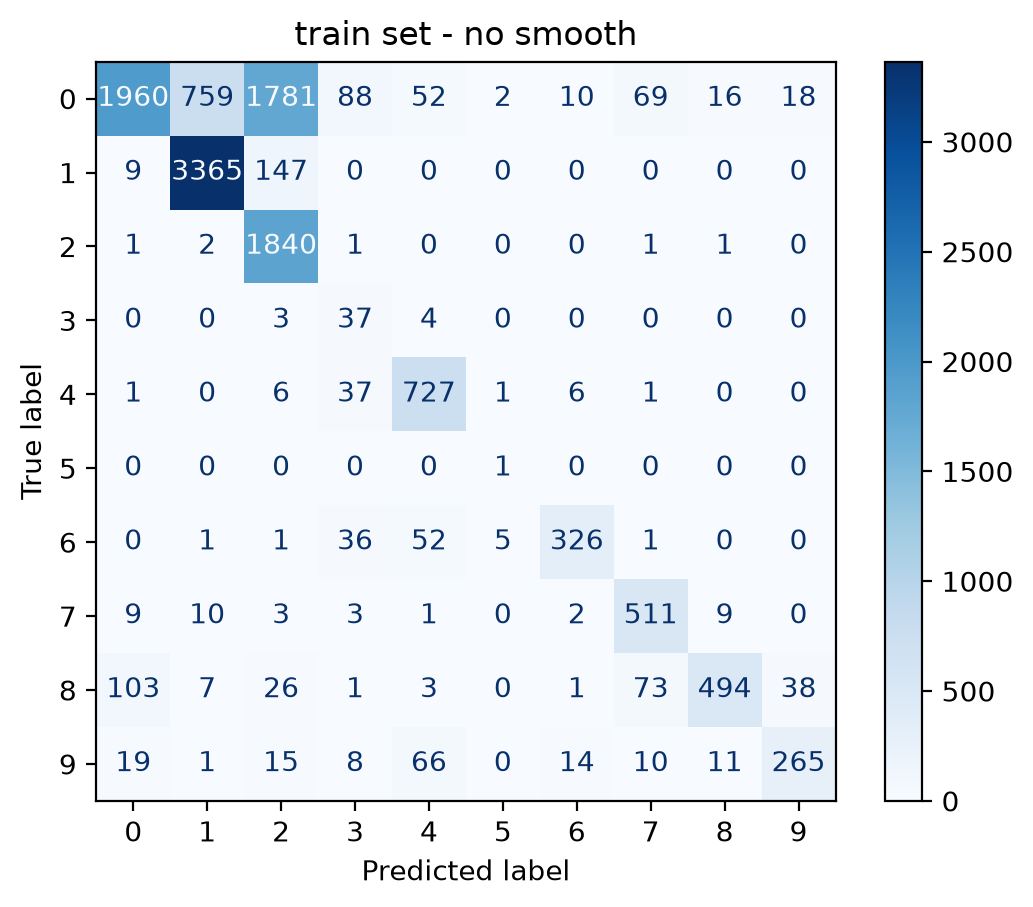

In [33]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("train set - no smooth")
# plt.savefig("plots/train_no_smooth.pdf")
plt.show()

#### with filter

In [34]:
X_flat_gauss = X_gauss[..., np.newaxis]

input_shape = (X_norm.shape[1], X_norm.shape[1], 1)
gauss_model = models.Sequential()
gauss_model.add(layers.Input(shape=(69, 69, 1)))

# block 1
gauss_model.add(layers.Conv2D(8, (3, 3), activation="relu", padding="same"))
gauss_model.add(layers.BatchNormalization())
gauss_model.add(layers.MaxPooling2D((2, 2)))

# block 2
gauss_model.add(layers.Conv2D(32, (5, 5), activation="relu", padding="same"))
gauss_model.add(layers.MaxPooling2D((2, 2)))

# block 3
gauss_model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
gauss_model.add(layers.BatchNormalization())
gauss_model.add(layers.MaxPooling2D((2, 2)))

# converts feature maps → single vector per feature map
gauss_model.add(layers.GlobalAveragePooling2D())

gauss_model.add(layers.Dense(32, activation='relu'))

# model.add(layers.Dropout(0.4))

gauss_model.add(layers.Dense(10, activation='softmax'))

In [35]:
gauss_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [36]:
history = gauss_model.fit(
    X_flat_gauss, y_train,
    epochs=50,
    batch_size=32,
    shuffle=True
)

2026-07-23 19:20:01.155123: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248924124 exceeds 10% of free system memory.


Epoch 1/50
409/409 [==============================] - 5s 9ms/step - loss: 0.2504 - accuracy: 0.4352
Epoch 2/50
409/409 [==============================] - 3s 8ms/step - loss: 0.1765 - accuracy: 0.5979
Epoch 3/50
409/409 [==============================] - 3s 8ms/step - loss: 0.1422 - accuracy: 0.6967
Epoch 4/50
409/409 [==============================] - 3s 8ms/step - loss: 0.1270 - accuracy: 0.7330
Epoch 5/50
409/409 [==============================] - 3s 8ms/step - loss: 0.1208 - accuracy: 0.7479
Epoch 6/50
409/409 [==============================] - 3s 8ms/step - loss: 0.1153 - accuracy: 0.7581
Epoch 7/50
409/409 [==============================] - 3s 9ms/step - loss: 0.1118 - accuracy: 0.7688
Epoch 8/50
409/409 [==============================] - 3s 8ms/step - loss: 0.1080 - accuracy: 0.7741
Epoch 9/50
409/409 [==============================] - 3s 8ms/step - loss: 0.1046 - accuracy: 0.7871
Epoch 10/50
409/409 [==============================] - 3s 8ms/step - loss: 0.1028 - accuracy: 0.7874

In [37]:
y_gauss = gauss_model.predict(X_flat_gauss)
y_pred = (y_gauss > 0.5).astype(int)
y_pred = np.argmax(y_gauss, axis=1)

409/409 [==============================] - 1s 2ms/step


In [38]:
y_true = np.argmax(y_train, axis=1)

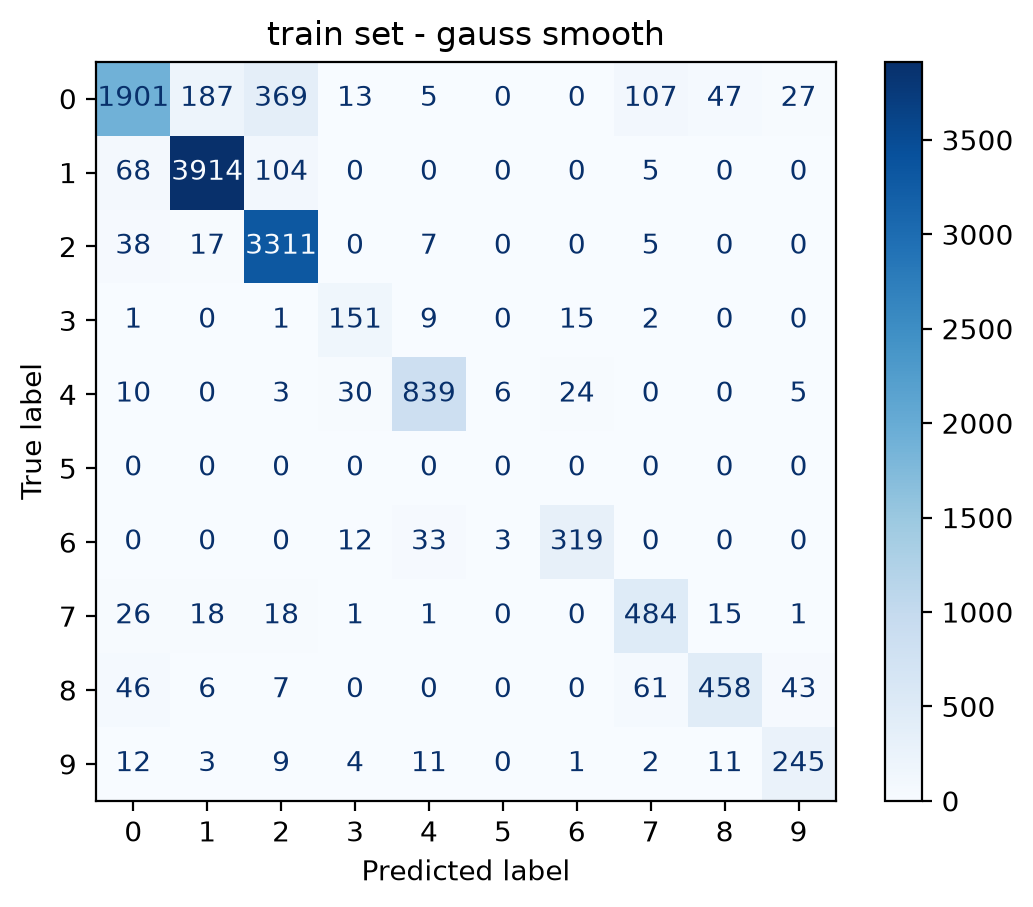

In [39]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("train set - gauss smooth")
# plt.savefig("plots/train_gauss_smooth.pdf")
plt.show()

### Testing

#### without filter

In [40]:
X_test_gray.shape

(8714, 69, 69)

In [41]:
# Min-max normalization (per-image)

X_min = X_test_gray.min(axis=(1,2), keepdims=True)  
X_max = X_test_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_test_gray - X_min) / (X_max - X_min + 1e-8)  

In [42]:
X_flat = X_norm[..., np.newaxis]
y_labels = np.argmax(y_test, axis=1)

In [43]:
y_pred = model.predict(X_flat)
y_pred = (y_pred > 0.5).astype(int)
y_pred = np.argmax(y_pred, axis=1)

273/273 [==============================] - 1s 4ms/step


In [44]:
y_true = np.argmax(y_test, axis=1)

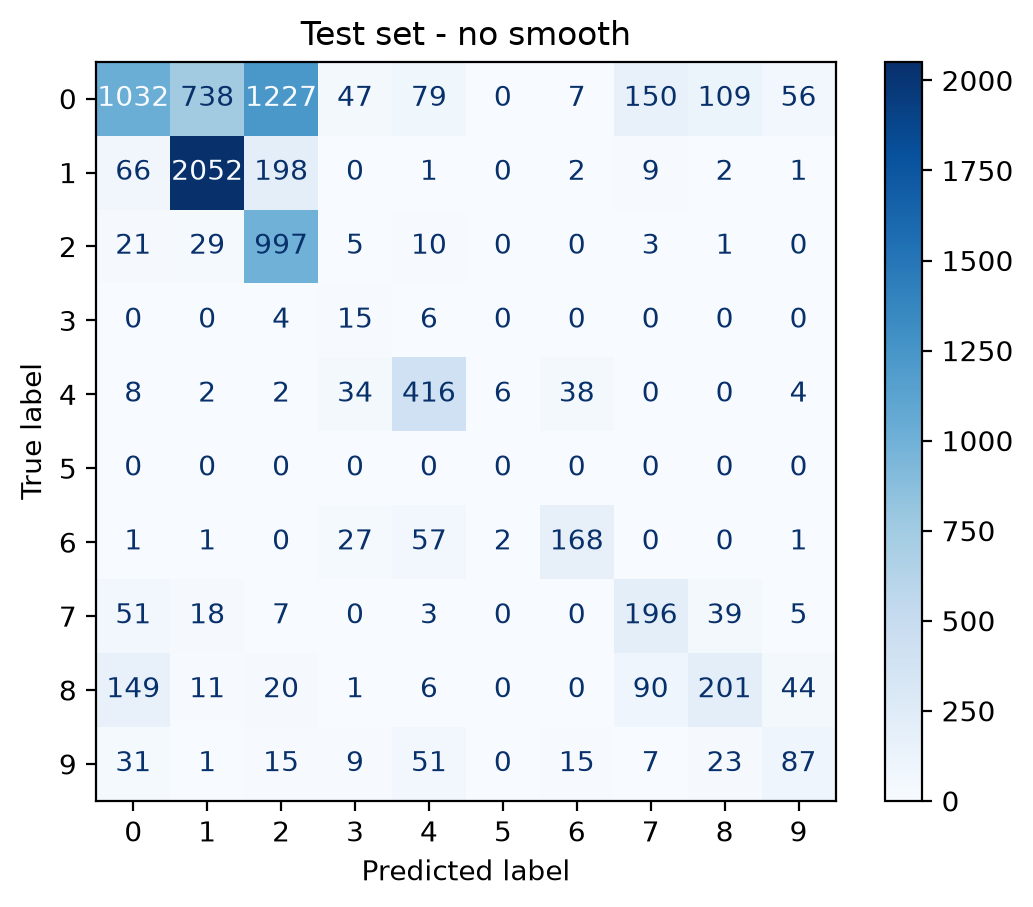

In [45]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test set - no smooth")
# plt.savefig("plots/test_no_smooth.pdf")
plt.show()

In [46]:
X_min = X_test_gray.min(axis=(1,2), keepdims=True)  
X_max = X_test_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_test_gray - X_min) / (X_max - X_min + 1e-8)  

X_gauss = gaussian_filter(X_norm, sigma=1, axes=[1,2])
X_flat = X_gauss[..., np.newaxis]

In [47]:
y_pred = gauss_model.predict(X_flat)
y_pred = (y_pred > 0.5).astype(int)
y_pred = np.argmax(y_pred, axis=1)

273/273 [==============================] - 1s 2ms/step


with filter

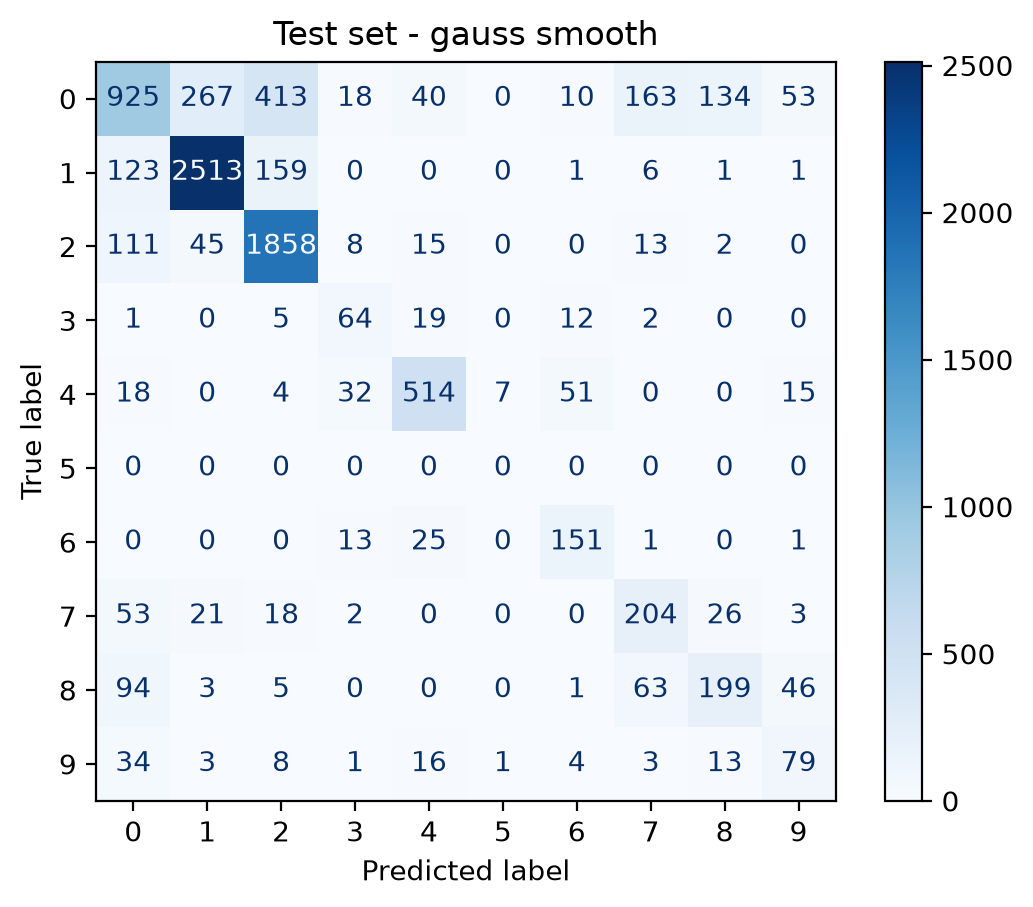

In [48]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test set - gauss smooth")
# plt.savefig("plots/test_gauss_smooth.pdf")
plt.show()

### Network inspect

1/1 [==============================] - 0s 400ms/step


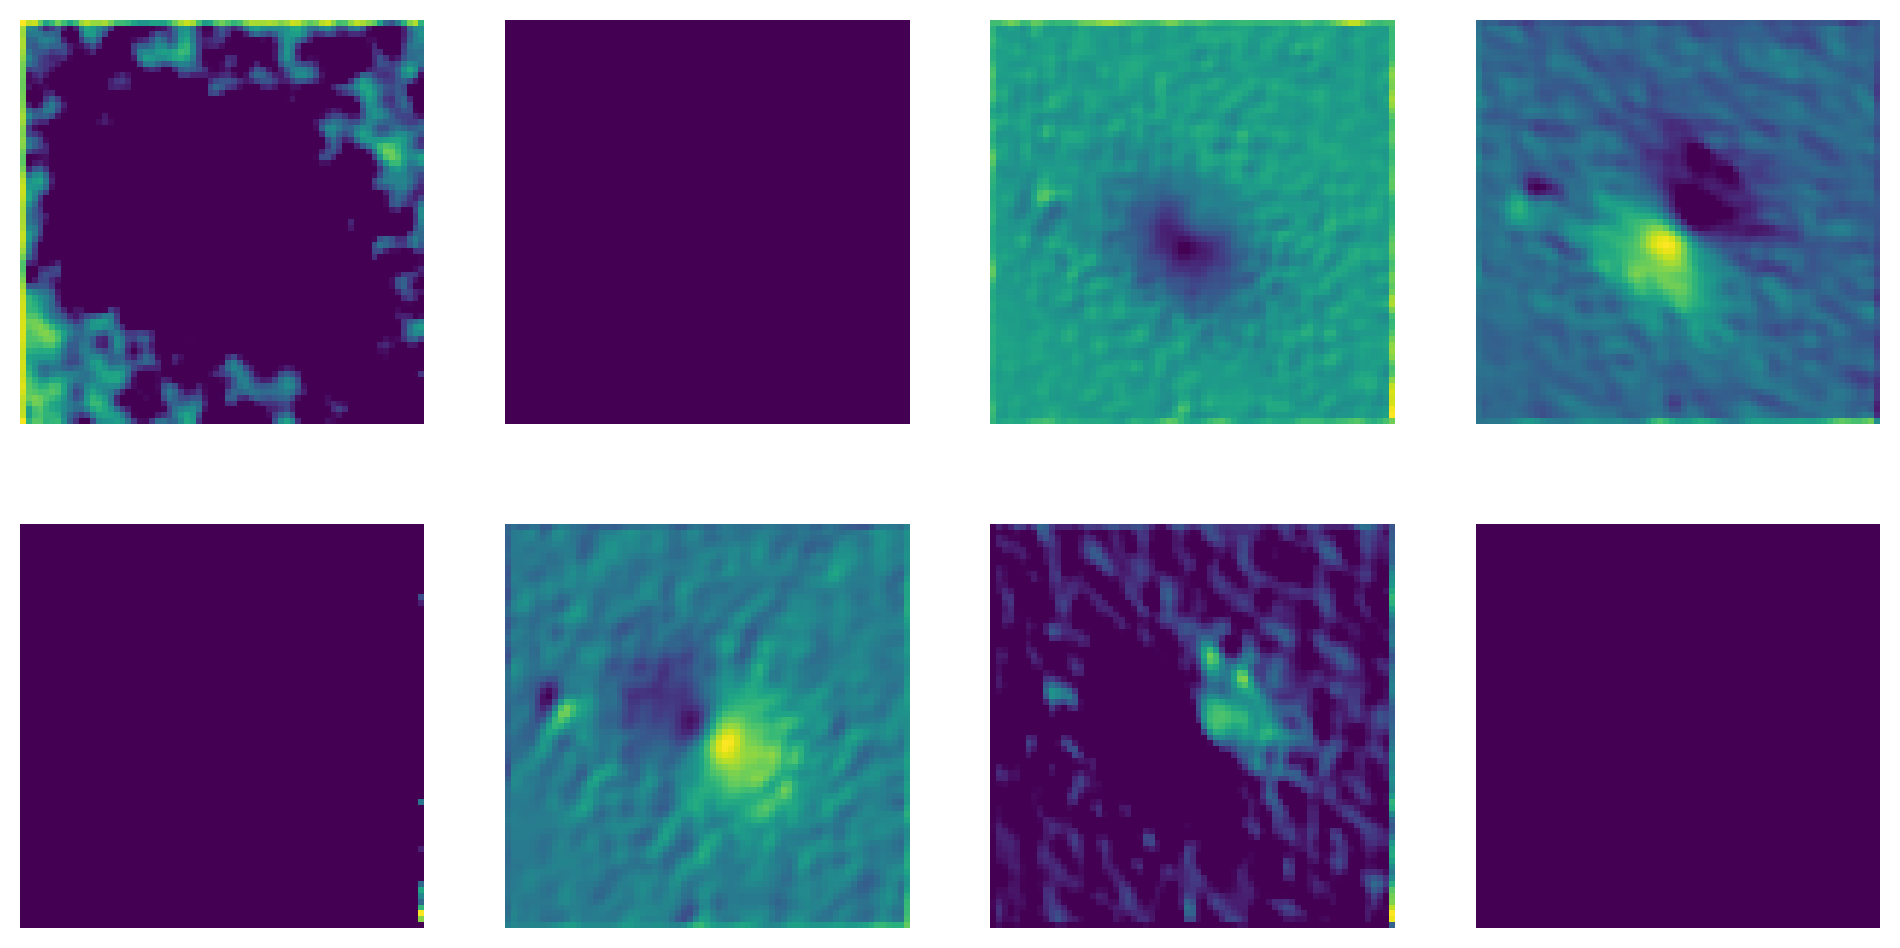

In [49]:
from tensorflow.keras.models import Model

layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

img = X_flat_gauss[0:1]  # one sample, shape (1, 69, 69, 1)
activations = activation_model.predict(img)

first_layer_activation = activations[0]  # (1, 69, 69, 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    ax.axis('off')
# plt.title("1st layer feature map - no smooth")
# plt.savefig("plots/1LayerFM_no_smooth.png")
plt.show()

1/1 [==============================] - 0s 56ms/step


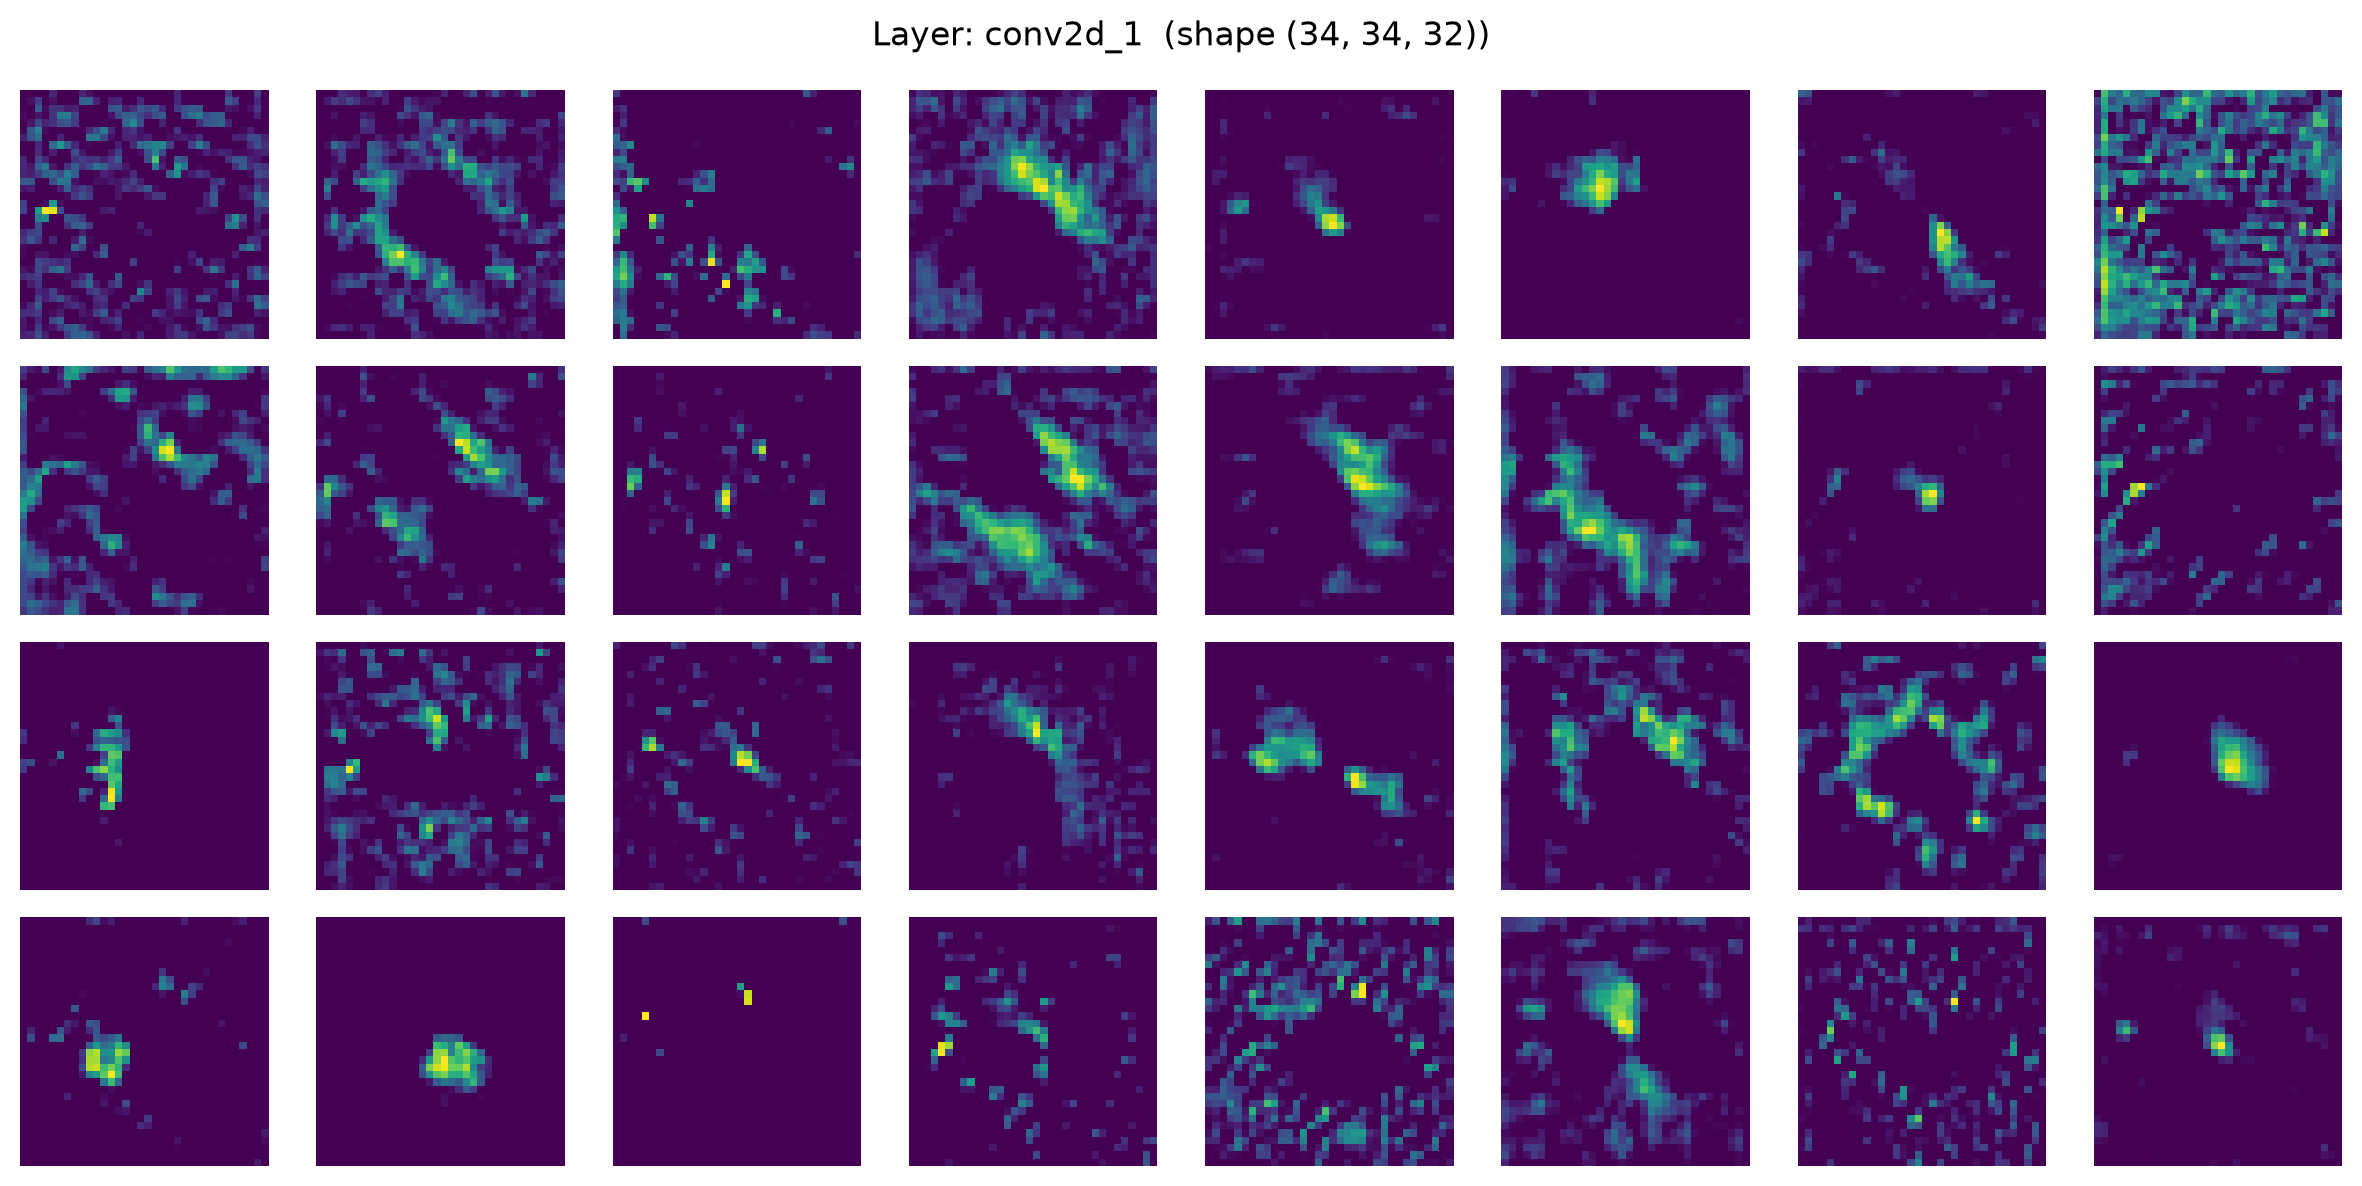

In [50]:
# 2. Grab every conv layer's output
conv_layers = [layer for layer in model.layers if 'conv' in layer.name]
layer_outputs = [layer.output for layer in conv_layers]
layer_names = [layer.name for layer in conv_layers]

activation_model = Model(inputs=model.input, outputs=layer_outputs)
activations = activation_model.predict(img)

# 3. Plot ONLY the second conv layer (index 1)
layer_name = layer_names[1]
activation = activations[1]

n_channels = activation.shape[-1]
n_cols = 8
n_rows = int(np.ceil(n_channels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
fig.suptitle(f"Layer: {layer_name}  (shape {activation.shape[1:]})", fontsize=12)

for i, ax in enumerate(axes.flat):
    if i < n_channels:
        ax.imshow(activation[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.tight_layout()
# plt.title("2nd layer feature map - no smooth")
# plt.savefig("plots/2LayerFM_no_smooth.pdf")
plt.show()

1/1 [==============================] - 0s 55ms/step


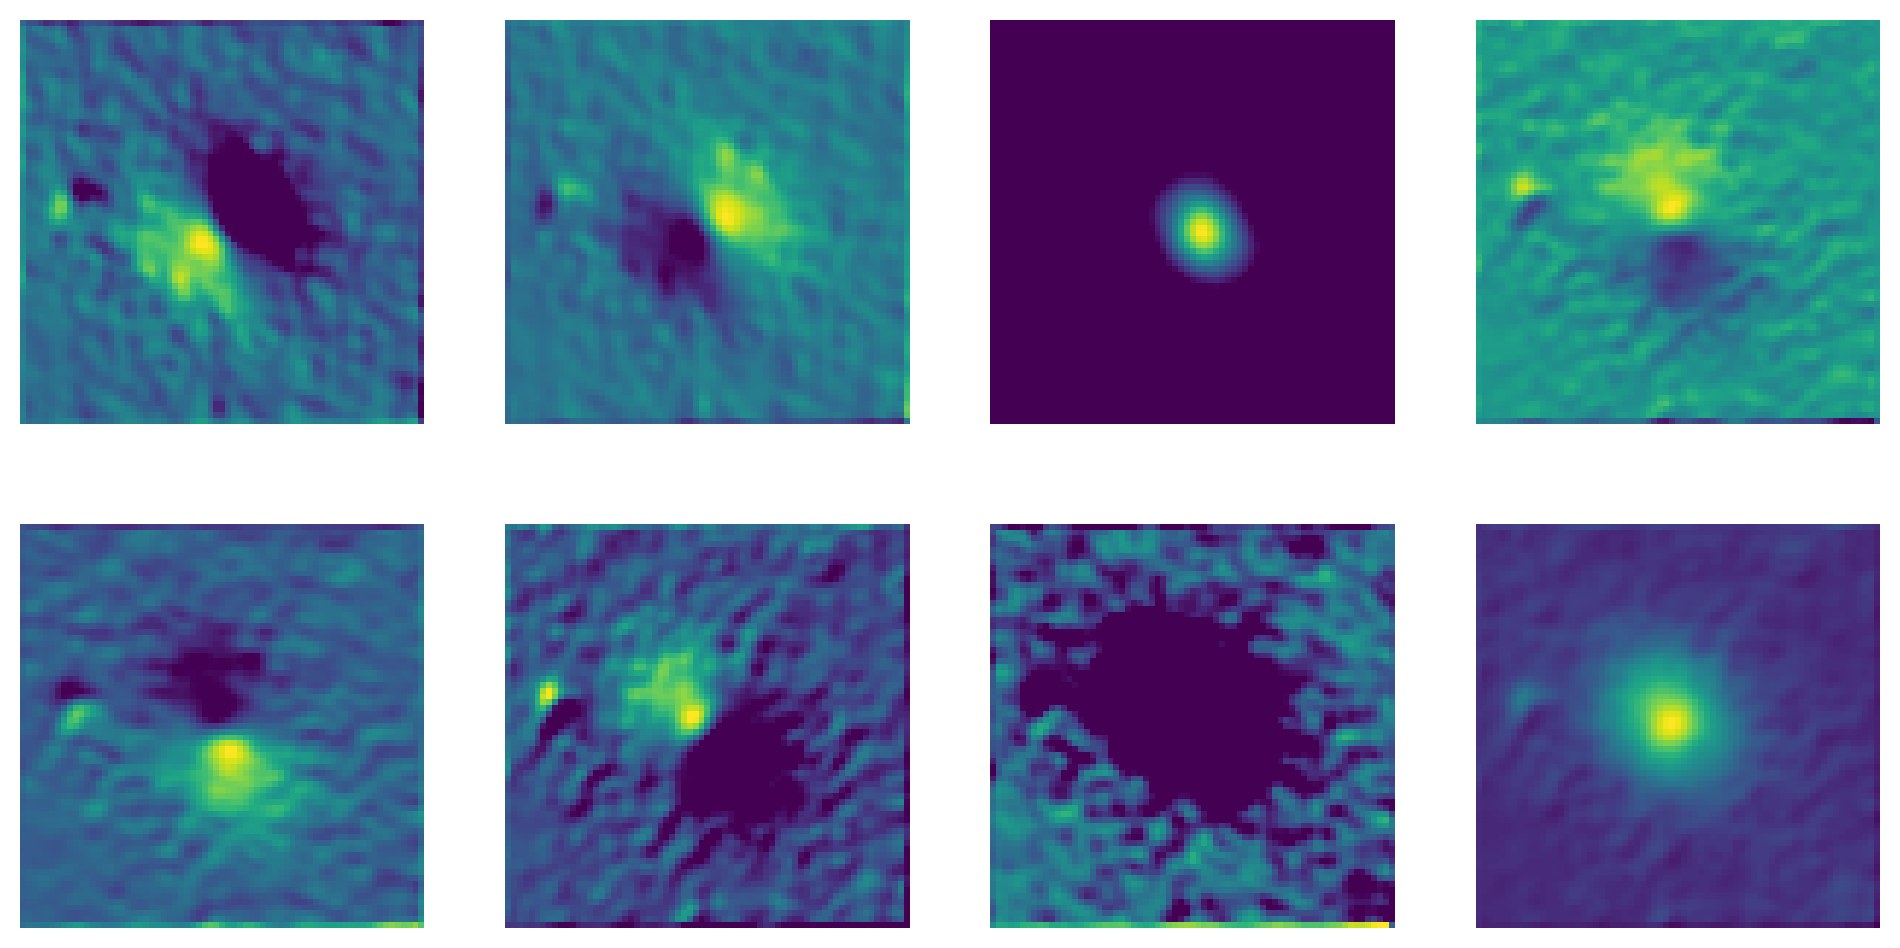

In [51]:
layer_outputs = [layer.output for layer in gauss_model.layers if 'conv' in layer.name]
activation_model = Model(inputs=gauss_model.input, outputs=layer_outputs)

img = X_flat_gauss[0:1]  # one sample, shape (1, 69, 69, 1)
activations = activation_model.predict(img)

first_layer_activation = activations[0]  # (1, 69, 69, 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    ax.axis('off')
# plt.title("1st layer feature map - gauss smooth")
# plt.savefig("plots/1LayerFM_gauss_smooth.png")
plt.show()

1/1 [==============================] - 0s 54ms/step


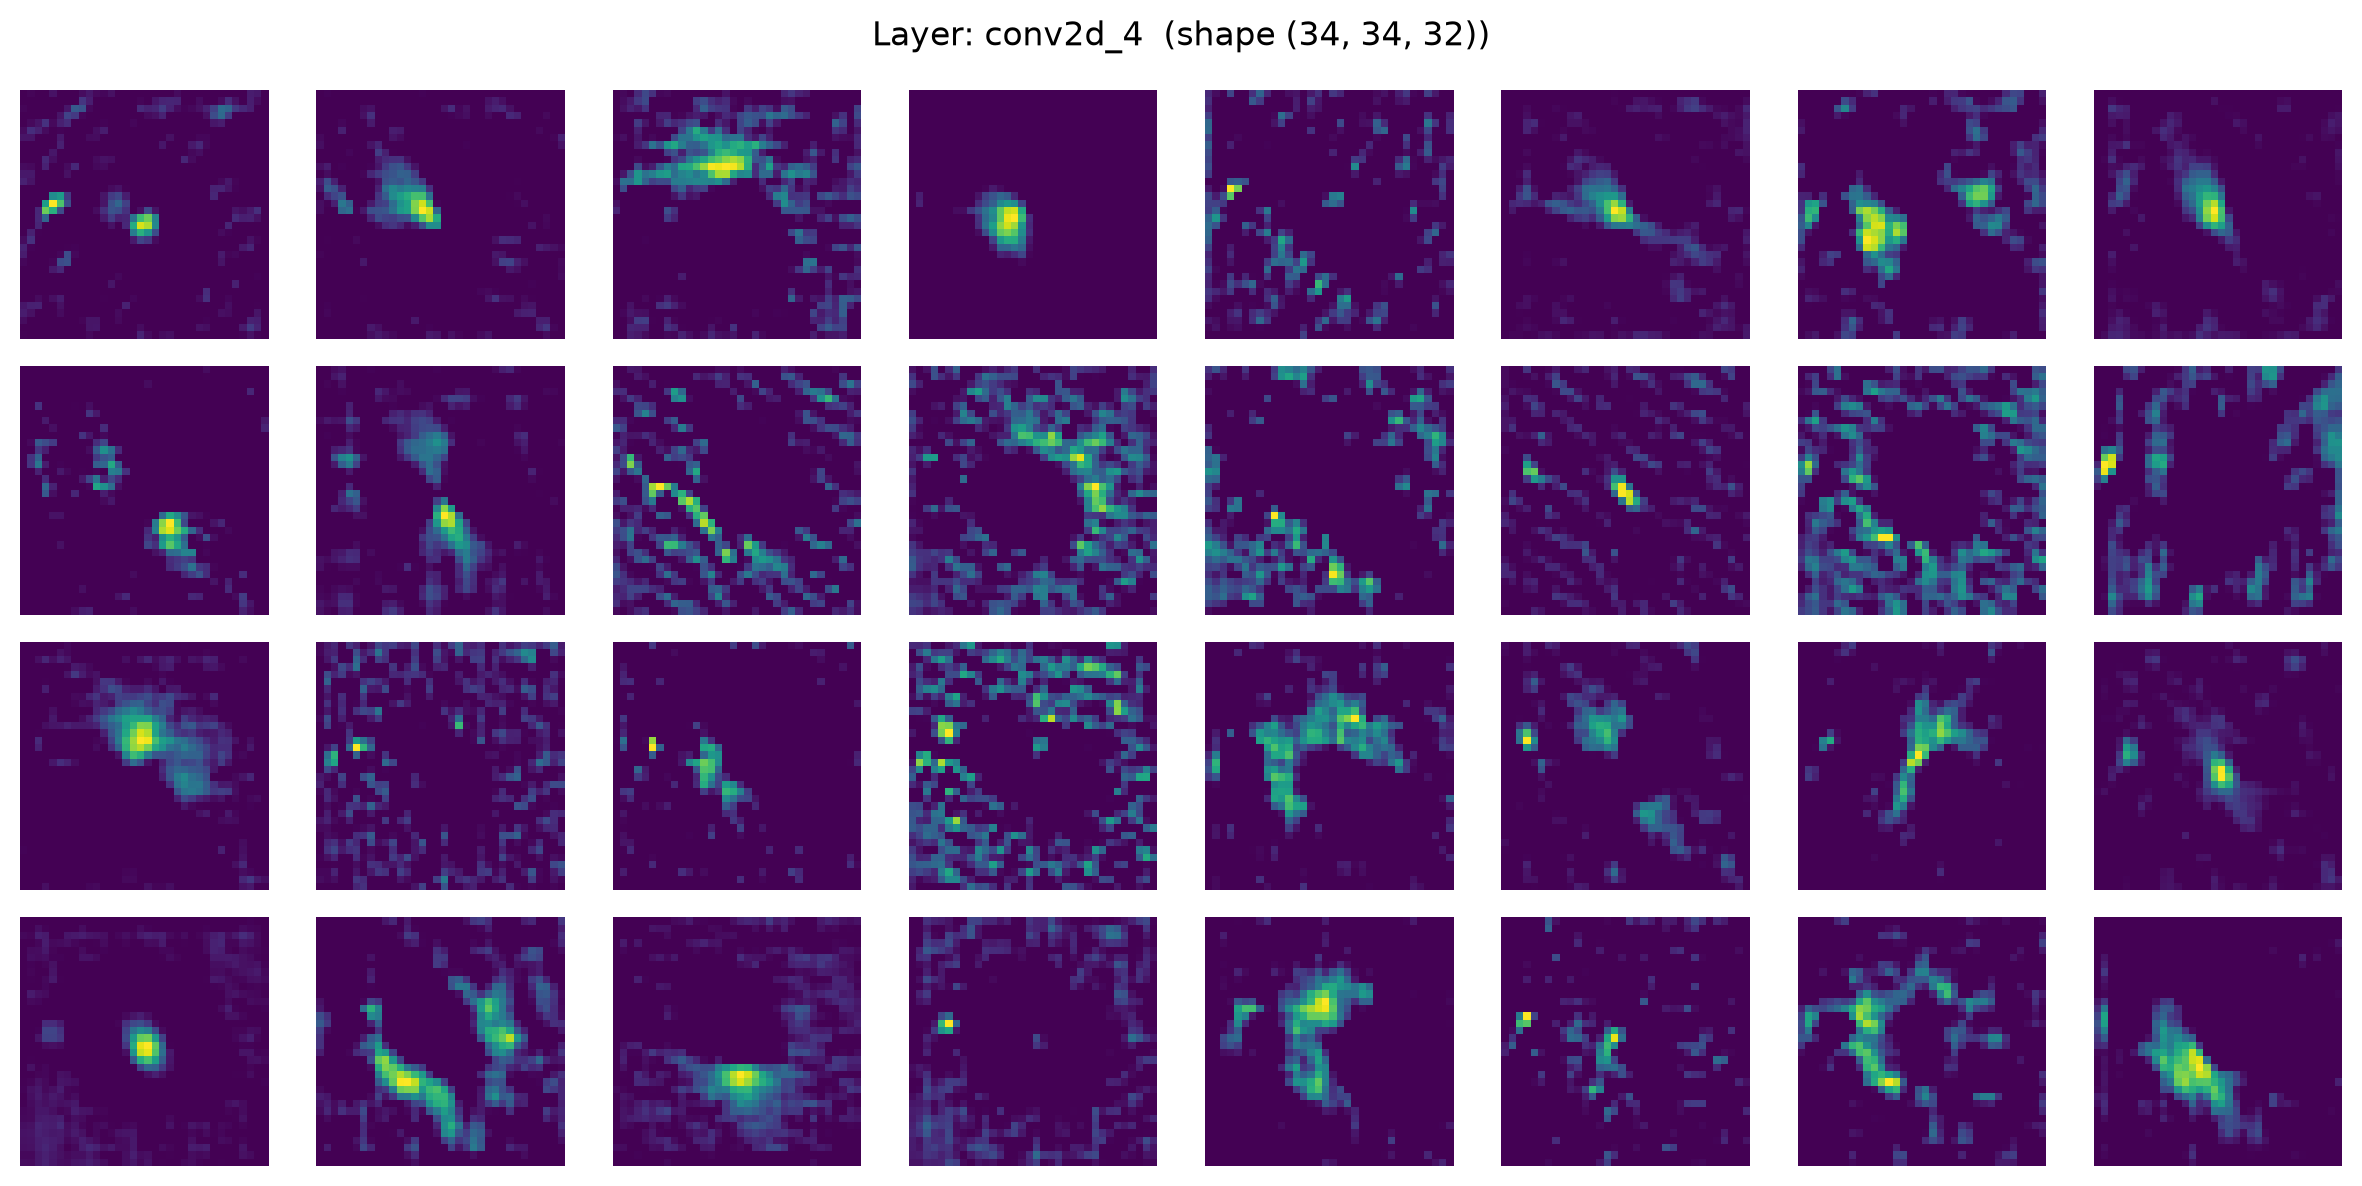

In [52]:
# 2. Grab every conv layer's output
conv_layers = [layer for layer in gauss_model.layers if 'conv' in layer.name]
layer_outputs = [layer.output for layer in conv_layers]
layer_names = [layer.name for layer in conv_layers]

activation_model = Model(inputs=gauss_model.input, outputs=layer_outputs)
activations = activation_model.predict(img)

# 3. Plot ONLY the second conv layer (index 1)
layer_name = layer_names[1]
activation = activations[1]

n_channels = activation.shape[-1]
n_cols = 8
n_rows = int(np.ceil(n_channels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
fig.suptitle(f"Layer: {layer_name}  (shape {activation.shape[1:]})", fontsize=12)

for i, ax in enumerate(axes.flat):
    if i < n_channels:
        ax.imshow(activation[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.tight_layout()
# plt.title("2nd layer feature map - gauss smooth")
# plt.savefig("plots/2LayerFM_gauss_smooth.pdf")
plt.show()